## Module 4: Algorithmic Bias Project
### By Jennifer Panula

#### ChatGPT assistance was used for some coding help and help to generate ideas on how to utilize the data for this analysis. 


In [1]:
#pip install geopandas

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Read the full provided file
df_mort = pd.read_csv('data/mortgage_covenant_data.csv')

In [4]:
df_mort.info(verbose = True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

In [5]:
df_mort.sample(5)

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
82354,2023,2.714500e+10,White,4,255000.0,NaN,68.0,NaN,25.67,81.34,10,0.0,False,NaN
40782,2023,2.712304e+10,Race Not Available,4,145000.0,NaN,142.0,NaN,38.30,79.79,10,0.0,False,NaN
95065,2023,2.703595e+10,White,1,655000.0,1255000.0,184.0,7.125,3.41,96.66,10,0.0,True,NaN
52699,2023,2.715749e+10,White,1,105000.0,NaN,55.0,NaN,6.78,94.92,1111,0.0,True,NaN
656,2023,2.704145e+10,White,1,145000.0,205000.0,54.0,6.500,8.74,96.09,10,0.0,True,NaN


### What is a Census Tract? 
**Geographic regions, typically several in each county, used for statistical division. Averages around 4000 inhabitants.
-Wikipedia https://en.wikipedia.org/wiki/Census_tract 

## Description of fields
- census_tract: 11 digit census tract number
- derived_race: Single aggregated race categorization derived from applicant/borrower and co-applicant/co-borrower race fields
- action_taken: The action taken on the covered loan or application
1 - Loan originated
2 - Application approved but not accepted
3 - Application denied
4 - Application withdrawn by applicant
5 - File closed for incompleteness
6 - Purchased loan
7 - Preapproval request denied
8 - Preapproval request approved but not accepted
  
- tract_minority_population_percent: Percentage of minority population to total population for tract, rounded to two decimal places
- tract_to_msa_income_percentage: Percentage of tract median family income compared to MSA/MD median family income (the midpoint of family income within a specific Metropolitan Statistical Area (MSA) or Metropolitan Division (MD), used to classify the income level of a census tract) https://apps.ffiec.gov/census/htm/2020CensusInfoSheet.htm 
- denial_reason-1: The principal reason, or reasons, for denial
1 - Debt-to-income ratio
2 - Employment history
3 - Credit history
4 - Collateral
5 - Insufficient cash (downpayment, closing costs)
6 - Unverifiable information
7 - Credit application incomplete
8 - Mortgage insurance denied
9 - Other
10 - Not applicable
- covenant_count:
- was_approved: Whether or not the loan application was approved
- covenant_density: derived field from provided file, categorizing density of covenants by low, medium, high or very high.

Descriptions largely located from https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields except the derived fields from the provided file for this project. 


## Initial exploration of Data

In [6]:
#exploring covenant density
df_mort['covenant_density'].describe()

count          11169
unique             4
top       Low (1-50)
freq            4537
Name: covenant_density, dtype: object

In [7]:
df_mort['covenant_density'].value_counts()

covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64

Text(0.5, 1.0, 'Covenant Density Category Counts')

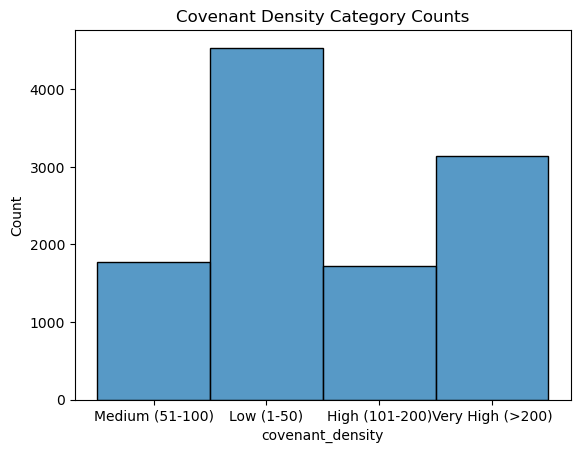

In [8]:
sns.histplot(df_mort['covenant_density'])
plt.title("Covenant Density Category Counts")

In [9]:
#are all NaNs in cov density zero cov?
condition_1 = (df_mort['covenant_count'] == 0) & (df_mort['covenant_density'].notna())
rows_condition_1 = df_mort[condition_1]
rows_condition_1

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density


In [10]:
condition_2 = (df_mort['covenant_count'] != 0) & (df_mort['covenant_density'].isna())
rows_condition_2 = df_mort[condition_2]
rows_condition_2

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density


In [11]:
#exploring covenant count
df_mort['covenant_count'].describe()

count    100931.000000
mean         17.408101
std          84.973673
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         965.000000
Name: covenant_count, dtype: float64

In [12]:
df_mort['covenant_count'].value_counts()

covenant_count
0.0      89762
1.0        684
3.0        532
2.0        488
212.0      294
         ...  
176.0       29
15.0        28
126.0       27
57.0        27
485.0       25
Name: count, Length: 112, dtype: int64

In [13]:
#112 distinct covenant counts, curious to see if this is a count of covenants by tract. Lets look at how many tracts there are...
df_mort['census_tract'].value_counts()

census_tract
2.705303e+10    606
2.716307e+10    580
2.705303e+10    432
2.705303e+10    420
2.717110e+10    384
               ... 
2.712304e+10      4
2.712303e+10      3
2.713700e+10      2
2.710900e+10      1
2.714501e+10      1
Name: count, Length: 1494, dtype: int64

In [14]:
df_no_cov = df_mort.groupby('census_tract').filter(lambda g: (g['covenant_count'] == 0).any())
df_no_cov

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,NaN
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,NaN
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,NaN
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,NaN


In [15]:
df_no_cov['census_tract'].value_counts()

census_tract
2.705303e+10    606
2.716307e+10    580
2.705303e+10    432
2.705303e+10    420
2.717110e+10    384
               ... 
2.712304e+10      4
2.712303e+10      3
2.713700e+10      2
2.710900e+10      1
2.714501e+10      1
Name: count, Length: 1333, dtype: int64

Out of the 1494 Census tracts in the file, 1333 had zero convenants. Thus, 161 or 10.78% of the tracts had covenants

In [16]:
#fill NaNs on the covenant_density field with None to create another category for comparison
df_mort['covenant_density'] = df_mort['covenant_density'].fillna('None')

In [17]:
#drop the NaNs on the census_tract field as this will be a key field for our analysis
df_mort= df_mort.dropna(subset=['census_tract'])


In [18]:
#filling other NaN values with Median among their census_tract

cols = ['property_value', 'income', 'interest_rate']

for col in cols:
    df_mort[col] = df_mort[col].fillna(
        df_mort.groupby('census_tract')[col].transform('median')
    )

In [19]:
df_mort.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99915 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      99915 non-null  int64  
 1   census_tract                       99915 non-null  float64
 2   derived_race                       99915 non-null  object 
 3   action_taken                       99915 non-null  int64  
 4   loan_amount                        99915 non-null  float64
 5   property_value                     99913 non-null  float64
 6   income                             99915 non-null  float64
 7   interest_rate                      99913 non-null  float64
 8   tract_minority_population_percent  99915 non-null  float64
 9   tract_to_msa_income_percentage     99915 non-null  float64
 10  denial_reason-1                    99915 non-null  int64  
 11  covenant_count                     99915 non-null  float64

In [20]:
#for some reason still just a few NaNs in some columns...I will drop them.
df_clean = df_mort.dropna()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99913 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      99913 non-null  int64  
 1   census_tract                       99913 non-null  float64
 2   derived_race                       99913 non-null  object 
 3   action_taken                       99913 non-null  int64  
 4   loan_amount                        99913 non-null  float64
 5   property_value                     99913 non-null  float64
 6   income                             99913 non-null  float64
 7   interest_rate                      99913 non-null  float64
 8   tract_minority_population_percent  99913 non-null  float64
 9   tract_to_msa_income_percentage     99913 non-null  float64
 10  denial_reason-1                    99913 non-null  int64  
 11  covenant_count                     99913 non-null  float64

In [21]:
#just in case i need it later - I may not do anything with it.
df_cove = df_mort[df_mort['covenant_density'] != "None"]
df_cove.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11169 entries, 36 to 100922
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      11169 non-null  int64  
 1   census_tract                       11169 non-null  float64
 2   derived_race                       11169 non-null  object 
 3   action_taken                       11169 non-null  int64  
 4   loan_amount                        11169 non-null  float64
 5   property_value                     11169 non-null  float64
 6   income                             11169 non-null  float64
 7   interest_rate                      11169 non-null  float64
 8   tract_minority_population_percent  11169 non-null  float64
 9   tract_to_msa_income_percentage     11169 non-null  float64
 10  denial_reason-1                    11169 non-null  int64  
 11  covenant_count                     11169 non-null  float6

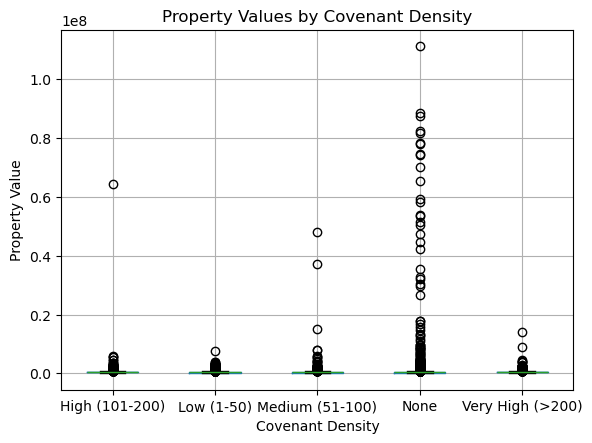

In [22]:
df_mort.boxplot(column='property_value', by='covenant_density')
plt.title('Property Values by Covenant Density')
plt.suptitle('')
plt.xlabel('Covenant Density')
plt.ylabel('Property Value')
plt.show()

In [23]:
#looking at property values to get an idea of how extreme the outliers are
df_mort['property_value'].describe()

count    9.991300e+04
mean     3.903163e+05
std      1.095897e+06
min      5.000000e+03
25%      2.350000e+05
50%      3.250000e+05
75%      4.350000e+05
max      1.113250e+08
Name: property_value, dtype: float64

In [24]:
# there's a lot of outliers (with property values), lets cut out the highest 1% 
cutoff = df_mort['property_value'].quantile(0.99)
df_no_outliers = df_mort[df_mort['property_value'] <= cutoff]
df_no_outliers

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,103.0,6.125,40.37,73.48,10,0.0,False,None
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,117.0,6.625,10.64,121.26,10,0.0,False,None
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,70.0,6.125,8.92,90.13,10,0.0,False,None
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,92.0,6.750,13.27,104.37,10,0.0,False,None
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,76.0,6.875,5.87,82.22,10,0.0,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,74.0,6.125,4.88,106.18,10,0.0,False,None
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,81.0,6.125,46.58,74.68,10,0.0,False,None
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,78.5,6.750,20.14,118.83,10,0.0,False,None
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,100.0,5.000,6.84,90.07,10,0.0,False,None


<Axes: xlabel='property_value', ylabel='Count'>

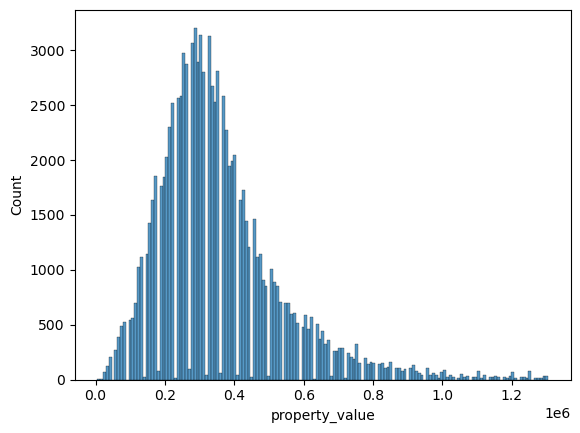

In [25]:
sns.histplot(df_no_outliers['property_value'])

In [26]:
#now the homes with higest values are $1.395M. 
df_no_outliers['property_value'].sort_values(ascending=False).head(10)

82410    1305000.0
74365    1305000.0
8692     1305000.0
74273    1305000.0
67058    1305000.0
31576    1305000.0
62325    1305000.0
28661    1305000.0
63196    1305000.0
63724    1305000.0
Name: property_value, dtype: float64

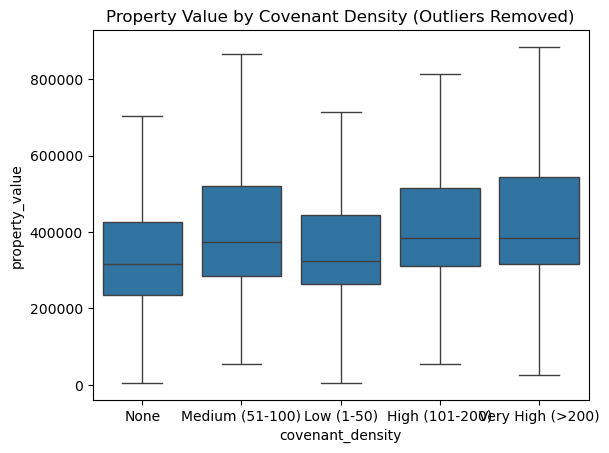

In [27]:
#outliers removed - the plots were still hard to visualize with the remaining outliers, even after the cutoff in prior code blocks.
sns.boxplot(x='covenant_density', y='property_value', data=df_mort, showfliers=False)
# sns.boxplot(x='covenant_density', y='property_value', data=df_no_outliers)
plt.title("Property Value by Covenant Density (Outliers Removed)")
plt.show()

In [28]:
#creating summary table as alternate to view relationship between these two paramaters
cov_value_summary = df_mort.groupby('covenant_density')['property_value'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)

cov_value_summary

,count,mean,median,std,min,max
covenant_density,,,,,,
High (101-200),1720,531078.488372,385000.0,1.600839e+06,55000.0,64405000.0
Low (1-50),4537,413259.863346,325000.0,3.166916e+05,5000.0,7625000.0
Medium (51-100),1772,551915.914221,375000.0,1.553047e+06,55000.0,48055000.0
None,88744,379267.837826,315000.0,1.113687e+06,5000.0,111325000.0
Very High (>200),3140,501119.426752,385000.0,4.591601e+05,25000.0,14205000.0


In [29]:
median_values = df_mort.groupby('covenant_density')['property_value'].median()
median_values

covenant_density
High (101-200)      385000.0
Low (1-50)          325000.0
Medium (51-100)     375000.0
None                315000.0
Very High (>200)    385000.0
Name: property_value, dtype: float64

In [30]:
order = ['None','Low (1-50)','Medium (51-100)','High (101-200)','Very High (>200)']

df_mort['covenant_density'] = pd.Categorical(
    df_mort['covenant_density'],
    categories=order,
    ordered=True
)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'None'),
  Text(1, 0, 'Low (1-50)'),
  Text(2, 0, 'Medium (51-100)'),
  Text(3, 0, 'High (101-200)'),
  Text(4, 0, 'Very High (>200)')])

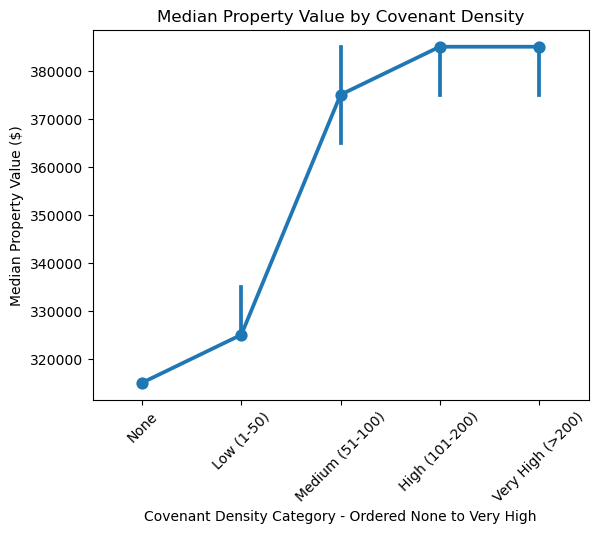

In [31]:
sns.pointplot(
    x='covenant_density',
    y='property_value',
    data=df_mort,
    estimator=np.median,
    order=order)
plt.title("Median Property Value by Covenant Density")
plt.xlabel("Covenant Density Category - Ordered None to Very High")
plt.ylabel("Median Property Value ($)")

plt.xticks(rotation=45)   # rotate x-axis labels


## Summary - Relationship between Covenant Density and Property Value

Going off the median (which is reasonable as the median is less influences by outliers), we see a correlation between density and property value, with the highest density categories having the highest median values and the lowest-to-none covenant densities correlating with the lower median values. 

# Now lets examine Approval trends


In [32]:
#average approval rate
df_mort['was_approved'].mean()

np.float64(0.6695290997347746)

In [33]:
#what does our dataset look like in regards to derived race?
df_mort['derived_race'].value_counts()

derived_race
White                                        62924
Race Not Available                           22626
Asian                                         5871
Black or African American                     5155
Joint                                         2411
American Indian or Alaska Native               685
2 or more minority races                       134
Native Hawaiian or Other Pacific Islander      104
Free Form Text Only                              5
Name: count, dtype: int64

Important to point out "Race not available" is the second-highest category. The non-white categories are quite unbalanced, so let's keep that in mind as we continue to explore the data. But meanwhile, let's get rid of "Free Form Text Only" field. 

In [34]:
df_mort = df_mort[df_mort['derived_race'] != "Free Form Text Only"]

In [35]:
#how about approval rates by race...
df_mort.groupby('derived_race')['was_approved'].mean().sort_values()

derived_race
Race Not Available                           0.407319
Black or African American                    0.608729
Native Hawaiian or Other Pacific Islander    0.615385
American Indian or Alaska Native             0.643796
2 or more minority races                     0.664179
Asian                                        0.711122
Joint                                        0.748237
White                                        0.762269
Name: was_approved, dtype: float64

In [36]:
df_mort['tract_minority_population_percent'].value_counts()

tract_minority_population_percent
20.69    649
27.78    580
10.98    573
14.61    441
9.08     432
        ... 
20.50      6
27.64      5
43.94      4
95.63      3
23.88      1
Name: count, Length: 1244, dtype: int64

In [37]:
df_mort['tract_minority_population_percent'].describe()

count    99910.000000
mean        23.106585
std         17.225704
min          2.030000
25%         10.250000
50%         18.800000
75%         29.780000
max         95.630000
Name: tract_minority_population_percent, dtype: float64

In [38]:
df_mort['minority_bin'] = pd.qcut(
    df_mort['tract_minority_population_percent'],
    4,
    labels=['Low','Medium-Low','Medium-High','High']
)

df_mort.groupby('minority_bin')['was_approved'].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_32588\2055272263.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('minority_bin')['was_approved'].mean()


minority_bin
Low            0.691991
Medium-Low     0.679091
Medium-High    0.666096
High           0.640568
Name: was_approved, dtype: float64

In [39]:
df_mort['income'].describe()

count    9.991000e+04
mean     1.441102e+02
std      5.232258e+03
min     -3.415700e+04
25%      7.000000e+01
50%      9.600000e+01
75%      1.420000e+02
max      1.651000e+06
Name: income, dtype: float64

In [40]:
#what's with the negative income? should we get rid of the negative income items?
df_mort['income'].sort_values(ascending=True).head(30)

72870   -34157.0
69936    -1661.0
58465     -994.0
43729     -196.0
92862     -108.0
22588      -93.0
7953       -93.0
64939      -54.0
47694      -51.0
59213      -45.0
11093      -45.0
11092      -45.0
11060      -38.0
92852      -35.0
92851      -29.0
92854      -14.0
70590      -10.0
69265       -8.0
7834        -8.0
33536       -7.0
92962       -5.0
75141       -3.0
13014        0.0
13145        0.0
15285        0.0
601          0.0
31650        0.0
7845         0.0
74245        0.0
87088        0.0
Name: income, dtype: float64

In [41]:
df_mort = df_mort[df_mort['income'] >= 0]
df_mort['income'].sort_values(ascending=True).head()

80652    0.0
84009    0.0
70546    0.0
80712    0.0
72747    0.0
Name: income, dtype: float64

In [42]:
df_mort['income_bin'] = pd.qcut(df_mort['income'], 4)

df_mort.groupby('income_bin')['was_approved'].mean()


C:\Users\jenpa\AppData\Local\Temp\ipykernel_32588\969461289.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('income_bin')['was_approved'].mean()


income_bin
(-0.001, 70.0]        0.633022
(70.0, 96.0]          0.643867
(96.0, 142.0]         0.657401
(142.0, 1651000.0]    0.745796
Name: was_approved, dtype: float64

Text(0.5, 1.0, 'Property Values by Loan Approval Decision (Outliers Removed)')

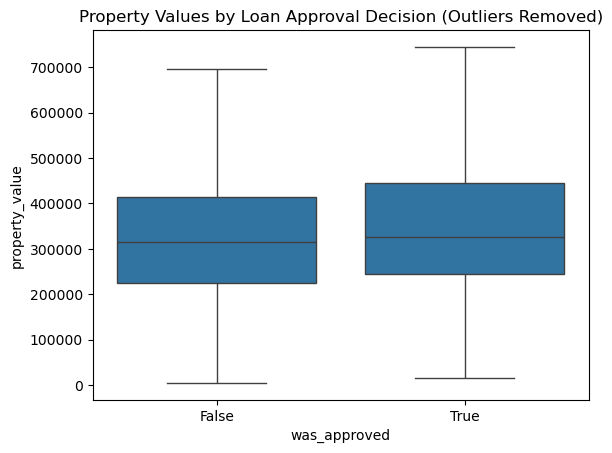

In [43]:
#approval vs proerty value
sns.boxplot(
    x='was_approved',
    y='property_value',
    data=df_mort, showfliers = False
)

plt.title("Property Values by Loan Approval Decision (Outliers Removed)")

In [44]:
df_mort.groupby('covenant_density')['was_approved'].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_32588\222843858.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('covenant_density')['was_approved'].mean()


covenant_density
None                0.669428
Low (1-50)          0.661376
Medium (51-100)     0.670429
High (101-200)      0.693248
Very High (>200)    0.673885
Name: was_approved, dtype: float64

Text(0.5, 1.0, 'Mortgage Approval Rates by Covenant Density')

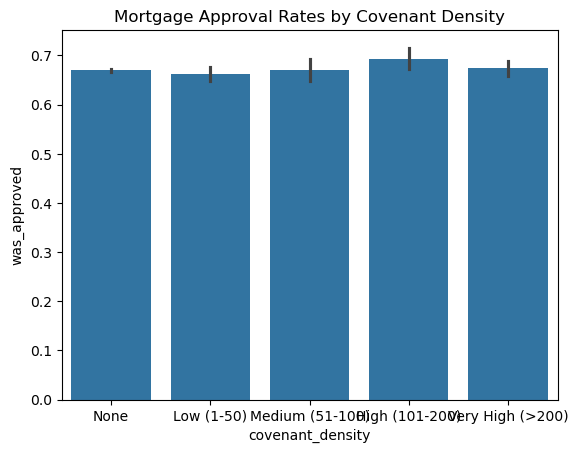

In [45]:
sns.barplot(
    x='covenant_density',
    y='was_approved',
    data=df_mort,
    estimator=np.mean, order= order
)

plt.title("Mortgage Approval Rates by Covenant Density")

In [46]:
df_mort['denial_reason-1'].value_counts()

denial_reason-1
10      91023
1111     3448
1        2117
3        1043
4         766
9         415
7         375
5         267
6         259
2         174
8           1
Name: count, dtype: int64

In [47]:
df_mort[df_mort['was_approved'] == 0]['denial_reason-1'].value_counts()

denial_reason-1
10      27139
1        2117
3        1043
4         766
1111      444
9         415
7         375
5         267
6         259
2         174
8           1
Name: count, dtype: int64

In [48]:
pd.crosstab(
    df_mort[df_mort['was_approved'] == 0]['derived_race'],
    df_mort[df_mort['was_approved'] == 0]['denial_reason-1']
)

denial_reason-1,1,2,3,4,5,6,7,8,9,10,1111
derived_race,,,,,,,,,,,
2 or more minority races,6,1,3,2,0,0,0,0,0,33,0
American Indian or Alaska Native,20,0,24,12,4,4,7,0,4,164,4
Asian,160,8,36,67,16,25,16,0,25,1335,7
Black or African American,245,20,91,55,42,35,28,0,35,1457,7
Joint,45,4,30,13,3,4,11,0,9,479,8
Native Hawaiian or Other Pacific Islander,5,1,5,1,1,0,0,0,1,26,0
Race Not Available,460,27,209,104,47,64,62,1,94,12168,172
White,1176,113,645,512,154,127,251,0,247,11477,246


I wondered about the many values for the code 10 which is N/A for denial reason. was_approved is a derived field,

combined_data['was_approved'] = combined_data['action_taken'].isin([1, 2])

with reason 2 being "approved but not accepted" and the other fields not all aligning with flat-out denial, I hypothesize that this may be part of the reason for so many N/A (denial reason 10) values here. 

## Patterns and Potential proxys for historical discrimination 

In [49]:
key_corr = df_mort[['covenant_count',
         'tract_minority_population_percent',
         'tract_to_msa_income_percentage',
         'property_value',
         'income']].corr()
key_corr

,covenant_count,tract_minority_population_percent,tract_to_msa_income_percentage,property_value,income
covenant_count,1.000000,0.017590,0.133837,0.023048,0.001376
tract_minority_population_percent,0.017590,1.000000,-0.435253,-0.019705,-0.001034
tract_to_msa_income_percentage,0.133837,-0.435253,1.000000,0.097336,0.006071
property_value,0.023048,-0.019705,0.097336,1.000000,0.002784
income,0.001376,-0.001034,0.006071,0.002784,1.000000


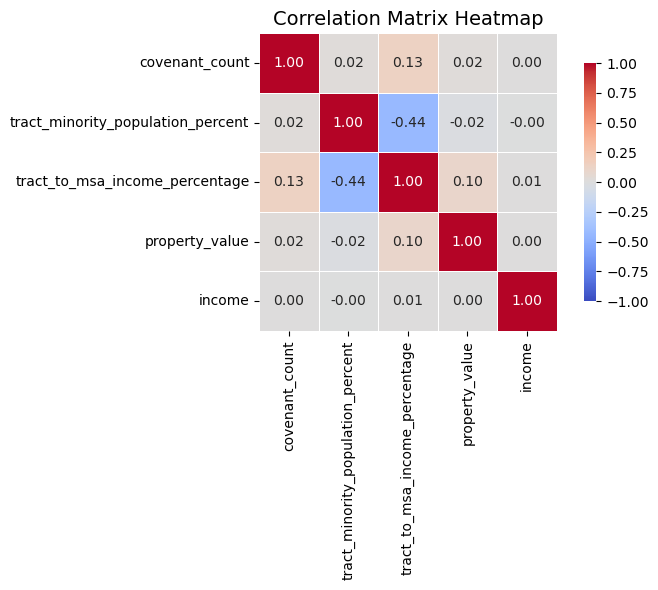

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    key_corr,
    annot=True,        # Show correlation values
    fmt=".2f",         # Format to 2 decimal places
    cmap='coolwarm',   # Color map
    vmin=-1, vmax=1,   # Fix scale from -1 to 1
    square=True,       # Make cells square
    linewidths=0.5,    # Add lines between cells
    cbar_kws={"shrink": 0.8}  # Colorbar size
)

plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
df_mort.groupby('covenant_density')['tract_minority_population_percent'].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_32588\1896031341.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('covenant_density')['tract_minority_population_percent'].mean()


covenant_density
None                22.192582
Low (1-50)          37.507597
Medium (51-100)     26.929069
High (101-200)      24.144924
Very High (>200)    25.431010
Name: tract_minority_population_percent, dtype: float64

<Axes: xlabel='covenant_density', ylabel='tract_minority_population_percent'>

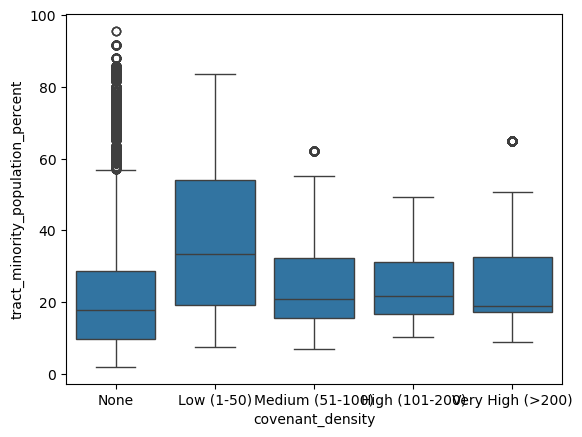

In [52]:
sns.boxplot(
    x='covenant_density',
    y='tract_minority_population_percent',
    data=df_mort
)

High covenant areas have lower minority populations, which suggests persistent segregation effects.

In [53]:
df_mort.groupby('covenant_density')['tract_to_msa_income_percentage'].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_32588\3659966123.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('covenant_density')['tract_to_msa_income_percentage'].mean()


covenant_density
None                101.830428
Low (1-50)           99.365866
Medium (51-100)     112.761580
High (101-200)      116.905972
Very High (>200)    123.291271
Name: tract_to_msa_income_percentage, dtype: float64

If covenant areas have higher neighborhood income relative to the metro, that suggests persistent economic advantages. However, in this case, only the low category is underpar by a small margin.

In [54]:
df_mort.groupby('covenant_density')[[
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'property_value'
]].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_32588\3387232275.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('covenant_density')[[


,tract_minority_population_percent,tract_to_msa_income_percentage,property_value
covenant_density,,,
None,22.192582,101.830428,379200.180343
Low (1-50),37.507597,99.365866,413201.058201
Medium (51-100),26.929069,112.761580,551915.914221
High (101-200),24.144924,116.905972,531120.488941
Very High (>200),25.431010,123.291271,501119.426752


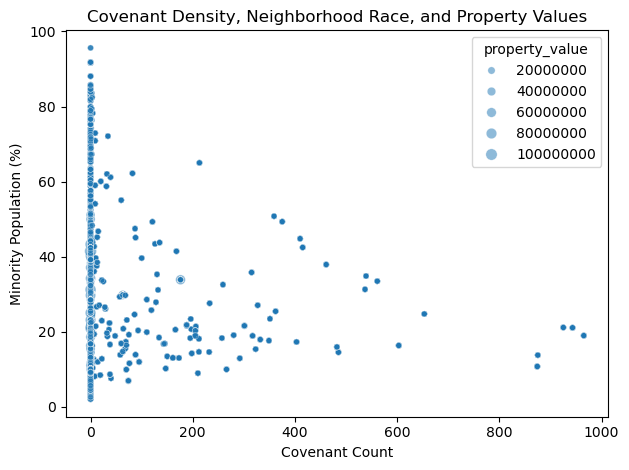

In [55]:
sns.scatterplot(
    x='covenant_count',
    y='tract_minority_population_percent',
    size='property_value',
    data=df_mort,
    alpha=0.5
)

plt.title("Covenant Density, Neighborhood Race, and Property Values")
plt.xlabel("Covenant Count")
plt.ylabel("Minority Population (%)")
plt.tight_layout()

sns.scatterplot(
    x='tract_to_msa_income_percentage',
    y='tract_minority_population_percent',
    hue='covenant_density',
    data=df_mort,
    alpha=0.6
)

plt.title("Neighborhood Race and Income by Covenant Density")
plt.xlabel("Income Relative to Metro Area (%)")
plt.ylabel("Minority Population (%)")
plt.show()

# ALgorithmic Bias
### Start with transforming object variables to numbers
### create some Regression models

In [56]:
df_mort.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99888 entries, 0 to 100930
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   activity_year                      99888 non-null  int64   
 1   census_tract                       99888 non-null  float64 
 2   derived_race                       99888 non-null  object  
 3   action_taken                       99888 non-null  int64   
 4   loan_amount                        99888 non-null  float64 
 5   property_value                     99886 non-null  float64 
 6   income                             99888 non-null  float64 
 7   interest_rate                      99886 non-null  float64 
 8   tract_minority_population_percent  99888 non-null  float64 
 9   tract_to_msa_income_percentage     99888 non-null  float64 
 10  denial_reason-1                    99888 non-null  int64   
 11  covenant_count                     99888 non-

My dataset has been slimmed down to 99886 after the earlier step where I removed the negative income values and the 5 observations where derived race was "free form text" 

In [58]:
df_mort['derived_race'].value_counts()

derived_race
White                                        62913
Race Not Available                           22620
Asian                                         5870
Black or African American                     5153
Joint                                         2410
American Indian or Alaska Native               684
2 or more minority races                       134
Native Hawaiian or Other Pacific Islander      104
Name: count, dtype: int64

In [66]:
#lets dummy-variable this
race_dummies = pd.get_dummies(df_mort['derived_race'], prefix='race', dtype=int)


In [64]:
#dropping highest count column
race_dummies = race_dummies.drop(['race_White'], axis=1)

In [70]:
df_mort = pd.concat([df_mort, race_dummies], axis = 1)

In [71]:
#adjust the bool was_approved to int
df_mort['was_approved'] = df_mort['was_approved'].astype(int)

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [74]:
import statsmodels.formula.api as smf

In [75]:
model = smf.ols(
    'property_value ~ covenant_count + tract_minority_population_percent + tract_to_msa_income_percentage',
    data=df_mort
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         property_value   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     342.1
Date:                Thu, 12 Mar 2026   Prob (F-statistic):          4.53e-221
Time:                        21:38:38   Log-Likelihood:            -1.5304e+06
No. Observations:               99886   AIC:                         3.061e+06
Df Residuals:                   99882   BIC:                         3.061e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [76]:
model = smf.logit(
    'was_approved ~ income + property_value + tract_minority_population_percent + covenant_count',
    data=df_mort
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.630049
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                99886
Model:                          Logit   Df Residuals:                    99881
Method:                           MLE   Df Model:                            4
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                0.006906
Time:                        21:40:10   Log-Likelihood:                -62933.
converged:                       True   LL-Null:                       -63371.
Covariance Type:            nonrobust   LLR p-value:                3.676e-188
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.5301      0.017     30

In [78]:
model = smf.logit(
    'was_approved ~ C(derived_race) + income + property_value + tract_to_msa_income_percentage',
    data=df_mort
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.583245
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                99886
Model:                          Logit   Df Residuals:                    99875
Method:                           MLE   Df Model:                           10
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.08068
Time:                        21:52:31   Log-Likelihood:                -58258.
converged:                       True   LL-Null:                       -63371.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercep

# Regression Results
Three regression models were ran, using a 0.05% p-value threshold for statistical significance. Very little evidence was found suggesting a connection with covenant count and/or racial profiles having a statistically significant weight on predicting property values or loan approvals.   
- Predicting Property value from covenant_count + tract_minority_population_percent + tract_to_msa_income_percentage resulted in an exceptionnally low R-squared value of 0.01 which indicates no relationship
- Predicting approval based on income + property_value + tract_minority_population_percent + covenant_count resulted in income and property_value being statistically significant to the approval probability, covanent_count being statistically insignificant. Notably, the tract_minority field was significant and slightly decreased probability of approval.  Pseudo R-squared of 0.007 indicates the model as weak, so even these model results are not a great fit for the predictor. 
- predicting approval based on race, income, property_value and MSA percentage resulted in none of the minorities showing any statisitcal significance to the model. Income, property value, MSA percentage shows as significant to the approval probability. The two race categories that were significant were White and Race not available, but this may be because these categories constituted the large majority of the data. Pseudo R-squared of 0.08 shows the weakness of this model, as well. 